In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correct way to load CSV file
titanic_data = pd.read_csv(r"C:\Users\Ashutosh Dubey\OneDrive\Desktop\Titanic-Dataset.csv")

# Display first 5 rows
print(titanic_data.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
titanic_data = pd.read_csv(r"C:\Users\Ashutosh Dubey\OneDrive\Desktop\Titanic-Dataset.csv")

# ============================================
# 1. BASIC INFO
# ============================================
print("Shape:", titanic_data.shape)
print("\nFirst 5 rows:")
print(titanic_data.head())
print("\nDataset Info:")
print(titanic_data.info())
print("\nMissing Values:")
print(titanic_data.isnull().sum())
print("\nBasic Statistics:")
print(titanic_data.describe())

Shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373

C:\Users\Ashutosh Dubey\AppData\Local\Temp\ipykernel_1220\2397912434.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=titanic_data, palette='Set2', ax=axes[0,0])
C:\Users\Ashutosh Dubey\AppData\Local\Temp\ipykernel_1220\2397912434.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['Died', 'Survived'])
C:\Users\Ashutosh Dubey\AppData\Local\Temp\ipykernel_1220\2397912434.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example,

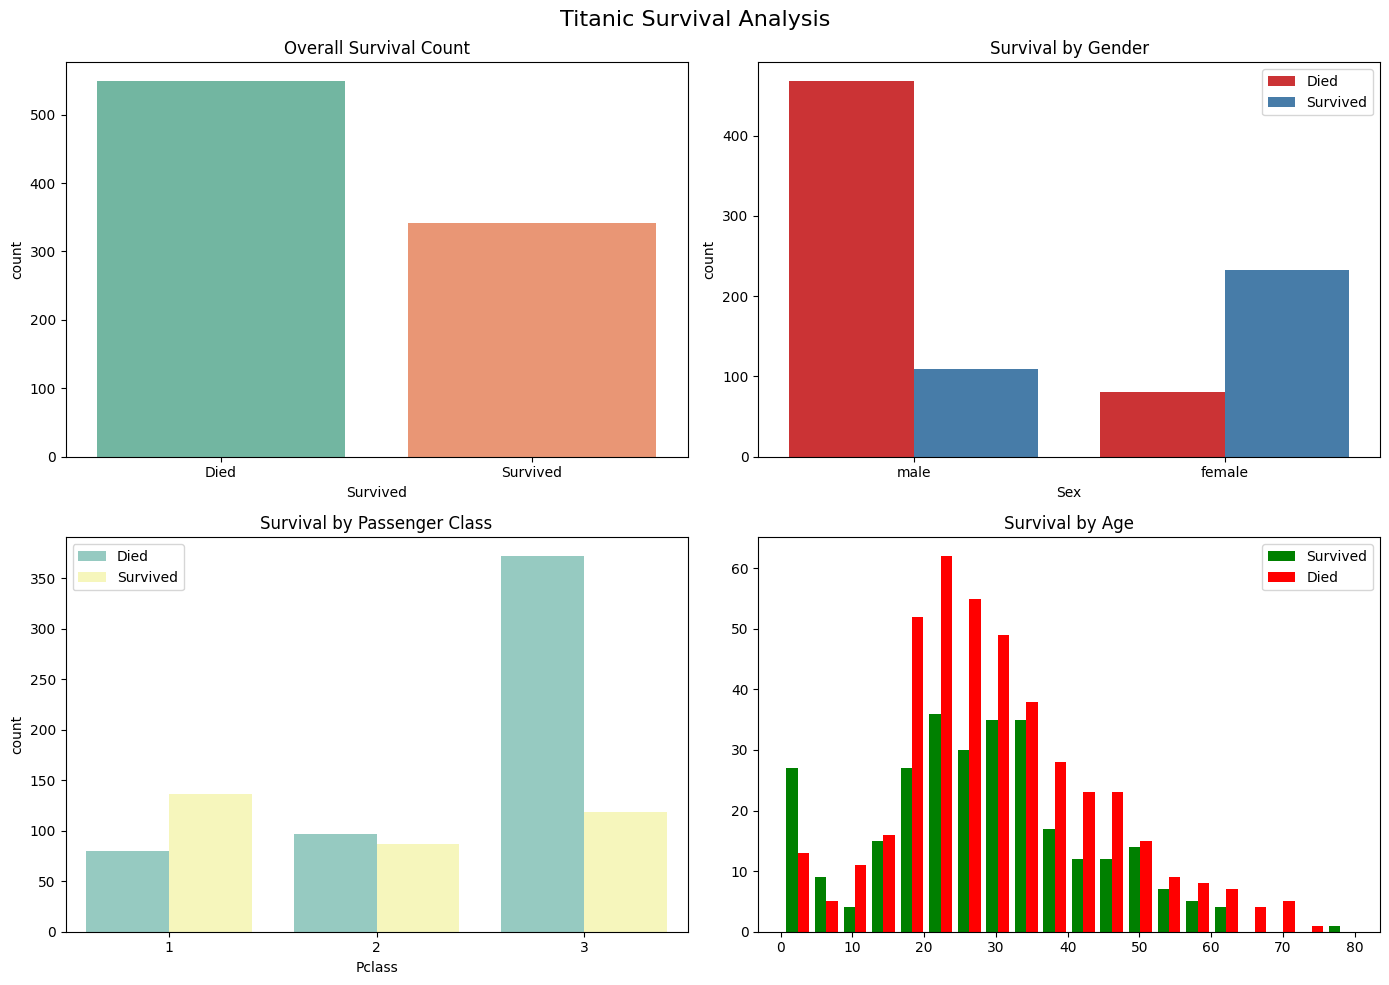

In [7]:
# ============================================
# 2. SURVIVAL ANALYSIS
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Titanic Survival Analysis", fontsize=16)

# Overall Survival Count
sns.countplot(x='Survived', data=titanic_data, palette='Set2', ax=axes[0,0])
axes[0,0].set_title("Overall Survival Count")
axes[0,0].set_xticklabels(['Died', 'Survived'])

# Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=titanic_data, palette='Set1', ax=axes[0,1])
axes[0,1].set_title("Survival by Gender")
axes[0,1].legend(['Died', 'Survived'])

# Survival by Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=titanic_data, palette='Set3', ax=axes[1,0])
axes[1,0].set_title("Survival by Passenger Class")
axes[1,0].legend(['Died', 'Survived'])

# Survival by Age
titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)
axes[1,1].hist([titanic_data[titanic_data['Survived']==1]['Age'],
                titanic_data[titanic_data['Survived']==0]['Age']],
                bins=20, label=['Survived', 'Died'], color=['green', 'red'])
axes[1,1].set_title("Survival by Age")
axes[1,1].legend()

plt.tight_layout()
plt.show()

C:\Users\Ashutosh Dubey\AppData\Local\Temp\ipykernel_1220\1103198409.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Fare', data=titanic_data, palette='coolwarm', ax=axes[0])


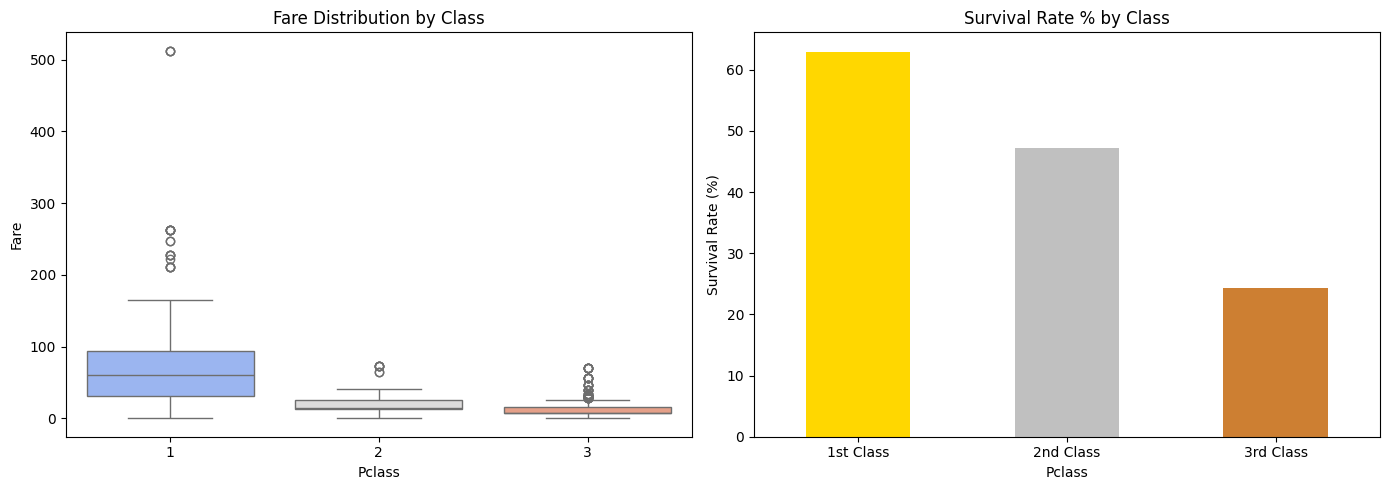

In [8]:
# ============================================
# 3. FARE & CLASS ANALYSIS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fare Distribution by Class
sns.boxplot(x='Pclass', y='Fare', data=titanic_data, palette='coolwarm', ax=axes[0])
axes[0].set_title("Fare Distribution by Class")

# Survival Rate by Class (%)
survival_rate = titanic_data.groupby('Pclass')['Survived'].mean() * 100
survival_rate.plot(kind='bar', color=['gold', 'silver', '#cd7f32'], ax=axes[1])
axes[1].set_title("Survival Rate % by Class")
axes[1].set_ylabel("Survival Rate (%)")
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)

plt.tight_layout()
plt.show()